In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
from kaggle_secrets import UserSecretsClient
import requests

KEY = UserSecretsClient().get_secret("OPENALEX_KEY")

r = requests.get(
    "https://api.openalex.org/works",
    params={"per_page": 1, "api_key": KEY},
    timeout=30,
)
print(r.status_code)
print(r.json()["meta"])

200
{'count': 326797579, 'db_response_time_ms': 153, 'page': 1, 'per_page': 1, 'groups_count': None, 'x_query': {'oql': 'works', 'oqo': {'get_rows': 'works'}, 'url': '/works?per_page=1'}, 'cost_usd': 0.0001}


In [2]:
# Is field id 17 really Computer Science?
f = requests.get("https://api.openalex.org/fields/17", params={"api_key": KEY}, timeout=30).json()
print(f["id"], "|", f["display_name"])

# How many English CS articles per year, 2019-2023?
r = requests.get(
    "https://api.openalex.org/works",
    params={
        "filter": "primary_topic.field.id:17,type:article,language:en,publication_year:2019-2023",
        "group_by": "publication_year",
        "api_key": KEY,
    },
    timeout=30,
).json()

for g in sorted(r["group_by"], key=lambda x: x["key"]):
    print(g["key"], g["count"])

https://openalex.org/fields/17 | Computer Science
2019 227160
2020 247042
2021 238904
2022 235098
2023 251718


In [3]:
r = requests.get(
    "https://api.openalex.org/subfields",
    params={"filter": "field.id:17", "per_page": 50, "api_key": KEY},
    timeout=30,
).json()

subs = r["results"]
print(len(subs), "subfields\n")
for s in sorted(subs, key=lambda x: -x["works_count"]):
    print(s["id"].split("/")[-1], "|", s["display_name"], "|", s["works_count"])

11 subfields

1702 | Artificial Intelligence | 8902427
1710 | Information Systems | 4344297
1705 | Computer Networks and Communications | 2701796
1707 | Computer Vision and Pattern Recognition | 2358569
1703 | Computational Theory and Mathematics | 1476944
1706 | Computer Science Applications | 745904
1711 | Signal Processing | 608463
1708 | Hardware and Architecture | 451124
1709 | Human-Computer Interaction | 393370
1704 | Computer Graphics and Computer-Aided Design | 259377
1712 | Software | 246818


In [4]:
r = requests.get(
    "https://api.openalex.org/works",
    params={
        "filter": "primary_topic.subfield.id:1702,type:article,language:en,publication_year:2019",
        "sample": 3,
        "seed": 42,
        "select": "id,title,publication_year,cited_by_count,counts_by_year",
        "api_key": KEY,
    },
    timeout=30,
).json()

for w in r["results"]:
    print(w["title"])
    print("year:", w["publication_year"], "| total cites:", w["cited_by_count"])
    for c in sorted(w["counts_by_year"], key=lambda x: x["year"]):
        print("  ", c["year"], c["cited_by_count"])
    print()

Separability gap and large-deviation entanglement criterion
year: 2019 | total cites: 7
   2020 1
   2021 3
   2023 2
   2024 1

Privacy by design in statistics: Should it become a default/standard?
year: 2019 | total cites: 1
   2020 1

IEEE Technology and Engineering Management Society
year: 2019 | total cites: 0



In [5]:
def cites_2yr(work):
    """Citations in years y+1 and y+2. A missing year counts as 0."""
    y = work["publication_year"]
    by_year = {c["year"]: c["cited_by_count"] for c in work["counts_by_year"]}
    return by_year.get(y + 1, 0) + by_year.get(y + 2, 0)

for w in r["results"]:
    print(cites_2yr(w), "|", w["title"][:60])

4 | Separability gap and large-deviation entanglement criterion
1 | Privacy by design in statistics: Should it become a default/
0 | IEEE Technology and Engineering Management Society


In [6]:
import time, pandas as pd

SEED = 42
SUBFIELDS = {
    1702: "Artificial Intelligence", 1710: "Information Systems",
    1705: "Computer Networks and Communications",
    1707: "Computer Vision and Pattern Recognition",
    1703: "Computational Theory and Mathematics",
    1706: "Computer Science Applications", 1711: "Signal Processing",
    1708: "Hardware and Architecture", 1709: "Human-Computer Interaction",
    1704: "Computer Graphics and Computer-Aided Design", 1712: "Software",
}
SELECT = ("id,title,publication_year,primary_topic,primary_location,"
          "referenced_works_count,cited_by_count,counts_by_year")

def cites_2yr(work):
    y = work["publication_year"]
    by_year = {c["year"]: c["cited_by_count"] for c in work["counts_by_year"]}
    return by_year.get(y + 1, 0) + by_year.get(y + 2, 0)

def get_page(params, tries=5):
    for i in range(tries):
        resp = requests.get("https://api.openalex.org/works", params=params, timeout=60)
        if resp.status_code == 200:
            return resp.json()["results"]
        time.sleep(2 * (i + 1))   # wait, then retry
    raise RuntimeError(f"Failed: {resp.status_code} {resp.text[:200]}")

def fetch_stratum(year, sub_id, n, per_page=100):
    filt = (f"primary_topic.subfield.id:{sub_id},type:article,language:en,"
            f"publication_year:{year},referenced_works_count:>0")
    rows = []
    for page in range(1, -(-n // per_page) + 1):
        results = get_page({"filter": filt, "sample": n, "seed": SEED,
                            "per_page": per_page, "page": page,
                            "select": SELECT, "api_key": KEY})
        for w in results:
            if not w.get("title"):
                continue
            src = (w.get("primary_location") or {}).get("source") or {}
            rows.append({
                "id": w["id"], "title": w["title"], "year": w["publication_year"],
                "subfield": SUBFIELDS[sub_id],
                "topic": (w.get("primary_topic") or {}).get("display_name"),
                "venue": src.get("display_name"),
                "n_references": w["referenced_works_count"],
                "cites_total": w["cited_by_count"],
                "cites_2yr": cites_2yr(w),
            })
    return pd.DataFrame(rows)

test = fetch_stratum(2019, 1702, 200)
print(test.shape, "| unique ids:", test["id"].nunique())
print(test.head(5).to_string())
print(test["cites_2yr"].describe())

(200, 9) | unique ids: 200
                                 id                                                                                                               title  year                 subfield                                        topic                                                                 venue  n_references  cites_total  cites_2yr
0  https://openalex.org/W2982416222                                                         Separability gap and large-deviation entanglement criterion  2019  Artificial Intelligence         Quantum Information and Cryptography                                                     Physical Review A            55            7          4
1  https://openalex.org/W2988650042                                               Privacy by design in statistics: Should it become a default/standard?  2019  Artificial Intelligence      Privacy-Preserving Technologies in Data                                       Statistical Journal of the IAOS    

In [7]:
from collections import Counter

chk = get_page({
    "filter": "primary_topic.subfield.id:1702,type:article,language:en,"
              "publication_year:2019,referenced_works_count:>0",
    "sample": 200, "seed": SEED, "per_page": 100, "page": 1,
    "select": "id,primary_topic", "api_key": KEY,
})

print(Counter(
    (w["primary_topic"] or {}).get("subfield", {}).get("display_name")
    for w in chk
))
print(Counter(
    (w["primary_topic"] or {}).get("field", {}).get("display_name")
    for w in chk
))

Counter({'Artificial Intelligence': 100})
Counter({'Computer Science': 100})


In [8]:
import os, glob

N_PER_STRATUM = 800
OUT_DIR = "/kaggle/working/strata"
os.makedirs(OUT_DIR, exist_ok=True)

strata = [(y, s) for y in range(2019, 2024) for s in SUBFIELDS]

for i, (year, sub_id) in enumerate(strata, 1):
    path = f"{OUT_DIR}/{year}_{sub_id}.parquet"
    if os.path.exists(path):
        continue                      # already done, resume
    df = fetch_stratum(year, sub_id, N_PER_STRATUM)
    df.to_parquet(path, index=False)
    print(f"[{i}/{len(strata)}] {year} {SUBFIELDS[sub_id]}: {len(df)} rows")

# Combine everything into one file
full = pd.concat([pd.read_parquet(p) for p in sorted(glob.glob(f"{OUT_DIR}/*.parquet"))],
                 ignore_index=True)
full = full.drop_duplicates("id").reset_index(drop=True)
full.to_parquet("/kaggle/working/citations_openalex.parquet", index=False)

print("\nTotal rows:", len(full))
print(full.groupby("year").size())
print(full.dtypes)

[1/55] 2019 Artificial Intelligence: 800 rows
[2/55] 2019 Information Systems: 800 rows
[3/55] 2019 Computer Networks and Communications: 800 rows
[4/55] 2019 Computer Vision and Pattern Recognition: 800 rows
[5/55] 2019 Computational Theory and Mathematics: 799 rows
[6/55] 2019 Computer Science Applications: 800 rows
[7/55] 2019 Signal Processing: 800 rows
[8/55] 2019 Hardware and Architecture: 800 rows
[9/55] 2019 Human-Computer Interaction: 800 rows
[10/55] 2019 Computer Graphics and Computer-Aided Design: 800 rows
[11/55] 2019 Software: 800 rows
[12/55] 2020 Artificial Intelligence: 800 rows
[13/55] 2020 Information Systems: 800 rows
[14/55] 2020 Computer Networks and Communications: 800 rows
[15/55] 2020 Computer Vision and Pattern Recognition: 800 rows
[16/55] 2020 Computational Theory and Mathematics: 800 rows
[17/55] 2020 Computer Science Applications: 800 rows
[18/55] 2020 Signal Processing: 800 rows
[19/55] 2020 Hardware and Architecture: 800 rows
[20/55] 2020 Human-Computer 

In [1]:
import glob
print(glob.glob("/kaggle/input/**/*.parquet", recursive=True))

['/kaggle/input/datasets/tharunganesh172/citations-openalex-cs-2019-2023/citations_openalex.parquet']


(43997, 9)
id                0
title             0
year              0
subfield          0
topic             0
venue           602
n_references      0
cites_total       0
cites_2yr         0
dtype: int64 

count    43997.000000
mean         6.955156
std         26.684423
min          0.000000
25%          0.000000
50%          2.000000
75%          7.000000
max       3050.000000
Name: cites_2yr, dtype: float64

Share of papers with 0 citations: 0.265
Quantiles:
 0.25     0.0
0.50     2.0
0.75     7.0
0.90    16.0
0.99    64.0
Name: cites_2yr, dtype: float64

       median   mean  share_zero
year                           
2019     2.0  6.419       0.291
2020     2.0  7.292       0.269
2021     3.0  6.544       0.257
2022     3.0  7.184       0.231
2023     2.0  7.336       0.278


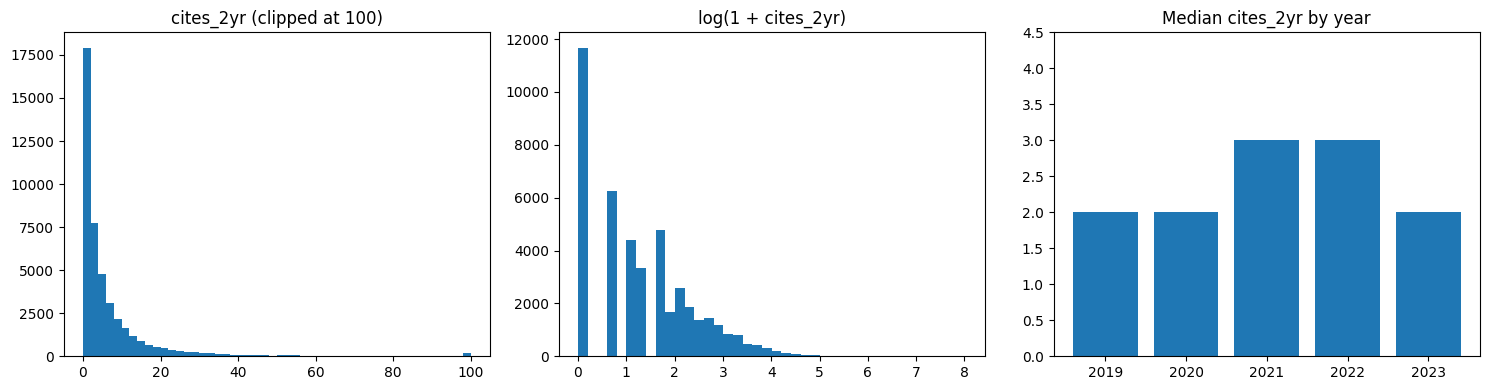

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, os

PATH = "/kaggle/input/datasets/tharunganesh172/citations-openalex-cs-2019-2023/citations_openalex.parquet"
df = pd.read_parquet(PATH)
os.makedirs("/kaggle/working/figures", exist_ok=True)

print(df.shape)
print(df.isna().sum(), "\n")

# 1. Shape of the target
print(df["cites_2yr"].describe())
print("\nShare of papers with 0 citations:", round((df["cites_2yr"] == 0).mean(), 3))
print("Quantiles:\n", df["cites_2yr"].quantile([.25, .5, .75, .9, .99]))

# 2. Year-flatness check
by_year = df.groupby("year")["cites_2yr"].agg(["median", "mean", lambda s: (s == 0).mean()])
by_year.columns = ["median", "mean", "share_zero"]
print("\n", by_year.round(3))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(df["cites_2yr"].clip(upper=100), bins=50)
ax[0].set_title("cites_2yr (clipped at 100)")
ax[1].hist(np.log1p(df["cites_2yr"]), bins=40)
ax[1].set_title("log(1 + cites_2yr)")
ax[2].bar(by_year.index.astype(str), by_year["median"])
ax[2].set_title("Median cites_2yr by year")
ax[2].set_ylim(0, max(by_year["median"].max() * 1.5, 1))
plt.tight_layout()
plt.savefig("/kaggle/working/figures/target_checks.png", dpi=150)
plt.show()

In [3]:
schemes = {
    "3 bands: 0 | 1-4 | 5+":            [-1, 0, 4, np.inf],
    "4 bands: 0 | 1-2 | 3-7 | 8+":      [-1, 0, 2, 7, np.inf],
    "4 bands: 0 | 1-3 | 4-9 | 10+":     [-1, 0, 3, 9, np.inf],
}

for name, edges in schemes.items():
    band = pd.cut(df["cites_2yr"], bins=edges, labels=False)
    print(name)
    print("  overall share:", band.value_counts(normalize=True).sort_index().round(3).tolist())
    print("  by year:")
    print(pd.crosstab(df["year"], band, normalize="index").round(3).to_string())
    print()

3 bands: 0 | 1-4 | 5+
  overall share: [0.265, 0.379, 0.356]
  by year:
cites_2yr      0      1      2
year                          
2019       0.291  0.375  0.334
2020       0.269  0.376  0.355
2021       0.257  0.380  0.364
2022       0.231  0.389  0.381
2023       0.278  0.376  0.346

4 bands: 0 | 1-2 | 3-7 | 8+
  overall share: [0.265, 0.242, 0.255, 0.238]
  by year:
cites_2yr      0      1      2      3
year                                 
2019       0.291  0.234  0.255  0.220
2020       0.269  0.234  0.256  0.240
2021       0.257  0.239  0.261  0.243
2022       0.231  0.254  0.264  0.251
2023       0.278  0.246  0.240  0.236

4 bands: 0 | 1-3 | 4-9 | 10+
  overall share: [0.265, 0.318, 0.228, 0.189]
  by year:
cites_2yr      0      1      2      3
year                                 
2019       0.291  0.309  0.225  0.175
2020       0.269  0.312  0.225  0.194
2021       0.257  0.318  0.235  0.191
2022       0.231  0.329  0.243  0.197
2023       0.278  0.321  0.213  0.187



In [4]:
from sklearn.model_selection import train_test_split

EDGES = [-1, 0, 2, 7, np.inf]
df["band"] = pd.cut(df["cites_2yr"], bins=EDGES, labels=False)

strat = df["band"].astype(str) + "_" + df["year"].astype(str)
idx_train, idx_tmp = train_test_split(df.index, test_size=0.30, random_state=42, stratify=strat)
idx_val, idx_test = train_test_split(idx_tmp, test_size=0.50, random_state=42, stratify=strat[idx_tmp])

split = pd.DataFrame({"id": df["id"], "band": df["band"], "split": "train"})
split.loc[idx_val, "split"] = "val"
split.loc[idx_test, "split"] = "test"
split.to_csv("/kaggle/working/split.csv", index=False)

print(split["split"].value_counts())
print(pd.crosstab(split["split"], split["band"], normalize="index").round(3))

split
train    30797
val       6600
test      6600
Name: count, dtype: int64
band       0      1      2      3
split                            
test   0.265  0.242  0.255  0.238
train  0.265  0.241  0.255  0.238
val    0.265  0.242  0.255  0.238


In [5]:
import os
import pandas as pd, numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

df = pd.read_parquet(PATH)
df["band"] = pd.cut(df["cites_2yr"], bins=[-1, 0, 2, 7, np.inf], labels=False)

# Use the frozen split (rebuild it with the same seed if the file is gone)
if os.path.exists("/kaggle/working/split.csv"):
    sp = pd.read_csv("/kaggle/working/split.csv")[["id", "split"]]
    df = df.merge(sp, on="id")
else:
    from sklearn.model_selection import train_test_split
    strat = df["band"].astype(str) + "_" + df["year"].astype(str)
    i_tr, i_tmp = train_test_split(df.index, test_size=0.30, random_state=42, stratify=strat)
    i_va, i_te = train_test_split(i_tmp, test_size=0.50, random_state=42, stratify=strat[i_tmp])
    df["split"] = "train"
    df.loc[i_va, "split"] = "val"
    df.loc[i_te, "split"] = "test"

train = df[df["split"] == "train"]
val = df[df["split"] == "val"]
print("train/val sizes:", len(train), len(val))

rows = []
for name, strategy in [("majority", "most_frequent"), ("random", "uniform"), ("stratified", "stratified")]:
    clf = DummyClassifier(strategy=strategy, random_state=42)
    clf.fit(train[["year"]], train["band"])
    pred = clf.predict(val[["year"]])
    rows.append({
        "model": name,
        "val_accuracy": round(accuracy_score(val["band"], pred), 3),
        "val_macro_f1": round(f1_score(val["band"], pred, average="macro"), 3),
    })

baselines = pd.DataFrame(rows)
print(baselines.to_string(index=False))
baselines.to_csv("/kaggle/working/baselines.csv", index=False)

train/val sizes: 30797 6600
     model  val_accuracy  val_macro_f1
  majority         0.265         0.105
    random         0.254         0.254
stratified         0.251         0.250


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50000,
                        sublinear_tf=True, lowercase=True)
X_train = tfidf.fit_transform(train["title"])   # fit on TRAIN only
X_val = tfidf.transform(val["title"])
print("feature matrix:", X_train.shape)

clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train, train["band"])
pred = clf.predict(X_val)

acc = accuracy_score(val["band"], pred)
mf1 = f1_score(val["band"], pred, average="macro")
print(f"\nval accuracy: {acc:.3f} | val macro-F1: {mf1:.3f}\n")
print(classification_report(val["band"], pred, digits=3))

# Log the run
results = pd.DataFrame([{
    "run": "lr_title_tfidf", "model": "LogisticRegression",
    "features": "title tfidf (1-2 grams)",
    "val_accuracy": round(acc, 3), "val_macro_f1": round(mf1, 3),
}])
results.to_csv("/kaggle/working/results_p1.csv", index=False)

feature matrix: (30797, 25902)

val accuracy: 0.361 | val macro-F1: 0.353

              precision    recall  f1-score   support

           0      0.402     0.484     0.439      1751
           1      0.266     0.214     0.237      1594
           2      0.296     0.270     0.282      1685
           3      0.440     0.469     0.454      1570

    accuracy                          0.361      6600
   macro avg      0.351     0.359     0.353      6600
weighted avg      0.351     0.361     0.354      6600



In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, C=1.0),
    "MultinomialNB": MultinomialNB(alpha=0.5),
    "LinearSVC": LinearSVC(C=0.3),
}

rows = []
for name, m in models.items():
    m.fit(X_train, train["band"])
    p = m.predict(X_val)
    f1s = f1_score(val["band"], p, average=None)
    rows.append({
        "run": f"{name}_title_tfidf", "model": name,
        "features": "title tfidf (1-2 grams)",
        "val_accuracy": round(accuracy_score(val["band"], p), 3),
        "val_macro_f1": round(f1_score(val["band"], p, average="macro"), 3),
        "f1_band0": round(f1s[0], 3), "f1_band1": round(f1s[1], 3),
        "f1_band2": round(f1s[2], 3), "f1_band3": round(f1s[3], 3),
    })

results = pd.DataFrame(rows)
print(results.drop(columns=["run", "features"]).to_string(index=False))
results.to_csv("/kaggle/working/results_p1.csv", index=False)

             model  val_accuracy  val_macro_f1  f1_band0  f1_band1  f1_band2  f1_band3
LogisticRegression         0.361         0.353     0.439     0.237     0.282     0.454
     MultinomialNB         0.368         0.358     0.444     0.230     0.304     0.452
         LinearSVC         0.357         0.349     0.436     0.239     0.271     0.449


In [8]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler

train = train.copy(); val = val.copy()
for d in (train, val):
    d["venue"] = d["venue"].fillna("Unknown")

def onehot_block(cols):
    enc = OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=3)
    return enc.fit_transform(train[cols]), enc.transform(val[cols])

sc = StandardScaler()
B = {
    "title": (X_train, X_val),
    "meta": onehot_block(["subfield", "topic", "year"]),
    "refs": (csr_matrix(sc.fit_transform(np.log1p(train[["n_references"]]))),
             csr_matrix(sc.transform(np.log1p(val[["n_references"]])))),
    "venue": onehot_block(["venue"]),
}
print("distinct venues in train:", train["venue"].nunique())

experiments = {
    "A1 without venue (title+metadata)": ["title", "meta", "refs"],
    "A2 with venue (everything)":        ["title", "meta", "refs", "venue"],
    "A3 venue only":                     ["venue"],
}

rows = []
for name, parts in experiments.items():
    Xtr = hstack([B[p][0] for p in parts]).tocsr()
    Xva = hstack([B[p][1] for p in parts]).tocsr()
    m = LogisticRegression(max_iter=2000, C=1.0).fit(Xtr, train["band"])
    p_ = m.predict(Xva)
    f1s = f1_score(val["band"], p_, average=None)
    rows.append({
        "run": name, "model": "LogisticRegression", "features": "+".join(parts),
        "val_accuracy": round(accuracy_score(val["band"], p_), 3),
        "val_macro_f1": round(f1_score(val["band"], p_, average="macro"), 3),
        "f1_band0": round(f1s[0], 3), "f1_band1": round(f1s[1], 3),
        "f1_band2": round(f1s[2], 3), "f1_band3": round(f1s[3], 3),
    })

ablA = pd.DataFrame(rows)
print(ablA.drop(columns=["model", "features"]).to_string(index=False))
ablA.to_csv("/kaggle/working/ablation_A.csv", index=False)

distinct venues in train: 7870
                              run  val_accuracy  val_macro_f1  f1_band0  f1_band1  f1_band2  f1_band3
A1 without venue (title+metadata)         0.434         0.425     0.544     0.270     0.343     0.542
       A2 with venue (everything)         0.458         0.450     0.574     0.287     0.359     0.578
                    A3 venue only         0.422         0.394     0.554     0.198     0.365     0.458


In [9]:
B["topic"] = onehot_block(["topic"])

experiments_B = {
    "B1 title only":                    ["title"],
    "B2 title + metadata (no venue)":   ["title", "meta", "refs"],
    "B3 metadata only (no title/venue)": ["meta", "refs"],
    "B4 topic only":                    ["topic"],
    "B5 n_references only":             ["refs"],
}

rows = []
for name, parts in experiments_B.items():
    Xtr = hstack([B[p][0] for p in parts]).tocsr()
    Xva = hstack([B[p][1] for p in parts]).tocsr()
    m = LogisticRegression(max_iter=2000, C=1.0).fit(Xtr, train["band"])
    p_ = m.predict(Xva)
    f1s = f1_score(val["band"], p_, average=None)
    rows.append({
        "run": name, "model": "LogisticRegression", "features": "+".join(parts),
        "val_accuracy": round(accuracy_score(val["band"], p_), 3),
        "val_macro_f1": round(f1_score(val["band"], p_, average="macro"), 3),
        "f1_band0": round(f1s[0], 3), "f1_band1": round(f1s[1], 3),
        "f1_band2": round(f1s[2], 3), "f1_band3": round(f1s[3], 3),
    })

ablB = pd.DataFrame(rows)
print(ablB.drop(columns=["model", "features"]).to_string(index=False))
ablB.to_csv("/kaggle/working/ablation_B.csv", index=False)

                              run  val_accuracy  val_macro_f1  f1_band0  f1_band1  f1_band2  f1_band3
                    B1 title only         0.361         0.353     0.439     0.237     0.282     0.454
   B2 title + metadata (no venue)         0.434         0.425     0.544     0.270     0.343     0.542
B3 metadata only (no title/venue)         0.446         0.427     0.572     0.236     0.356     0.543
                    B4 topic only         0.365         0.333     0.444     0.100     0.334     0.454
             B5 n_references only         0.420         0.397     0.566     0.183     0.332     0.508


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

dev = pd.concat([train, val], ignore_index=True)
dev["venue"] = dev["venue"].fillna("Unknown")
dev["log_refs"] = np.log1p(dev["n_references"])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(skf.split(dev, dev["band"].astype(str) + "_" + dev["year"].astype(str)))

def make_block(name):
    if name == "title":
        return ("title", TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50000,
                                         sublinear_tf=True), "title")
    if name == "meta":
        return ("meta", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=3),
                ["subfield", "topic", "year"])
    if name == "refs":
        return ("refs", StandardScaler(), ["log_refs"])
    if name == "venue":
        return ("venue", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=3),
                ["venue"])

configs = {
    "title only":                ["title"],
    "n_references only":         ["refs"],
    "venue only":                ["venue"],
    "metadata only (no venue)":  ["meta", "refs"],
    "title + metadata":          ["title", "meta", "refs"],
    "everything (with venue)":   ["title", "meta", "refs", "venue"],
}

rows = []
for name, parts in configs.items():
    pipe = Pipeline([
        ("cols", ColumnTransformer([make_block(p) for p in parts])),
        ("clf", LogisticRegression(max_iter=2000, C=1.0)),
    ])
    s = cross_val_score(pipe, dev, dev["band"], cv=folds, scoring="f1_macro", n_jobs=1)
    rows.append({"features": name, "cv_macro_f1_mean": round(s.mean(), 3),
                 "cv_macro_f1_std": round(s.std(), 3)})
    print(rows[-1])

cv = pd.DataFrame(rows)
cv.to_csv("/kaggle/working/cv_results.csv", index=False)
print("\n", cv.to_string(index=False))

{'features': 'title only', 'cv_macro_f1_mean': np.float64(0.365), 'cv_macro_f1_std': np.float64(0.004)}
{'features': 'n_references only', 'cv_macro_f1_mean': np.float64(0.405), 'cv_macro_f1_std': np.float64(0.002)}
{'features': 'venue only', 'cv_macro_f1_mean': np.float64(0.401), 'cv_macro_f1_std': np.float64(0.007)}
{'features': 'metadata only (no venue)', 'cv_macro_f1_mean': np.float64(0.427), 'cv_macro_f1_std': np.float64(0.005)}
{'features': 'title + metadata', 'cv_macro_f1_mean': np.float64(0.427), 'cv_macro_f1_std': np.float64(0.005)}
{'features': 'everything (with venue)', 'cv_macro_f1_mean': np.float64(0.456), 'cv_macro_f1_std': np.float64(0.005)}

                 features  cv_macro_f1_mean  cv_macro_f1_std
              title only             0.365            0.004
       n_references only             0.405            0.002
              venue only             0.401            0.007
metadata only (no venue)             0.427            0.005
        title + metadata          

In [11]:
import os
need = ["baselines.csv", "results_p1.csv", "ablation_A.csv", "ablation_B.csv", "cv_results.csv"]
have = os.listdir("/kaggle/working")
for f in need:
    print(("OK      " if f in have else "MISSING ") + f)

OK      baselines.csv
OK      results_p1.csv
OK      ablation_A.csv
OK      ablation_B.csv
OK      cv_results.csv


                features  test_accuracy  test_macro_f1  f1_band0  f1_band1  f1_band2  f1_band3
       majority baseline          0.265          0.105       NaN       NaN       NaN       NaN
              title only          0.368          0.360     0.451     0.235     0.297     0.458
       n_references only          0.418          0.395     0.568     0.182     0.320     0.511
              venue only          0.431          0.403     0.567     0.220     0.320     0.504
metadata only (no venue)          0.443          0.422     0.577     0.217     0.347     0.549
        title + metadata          0.430          0.419     0.550     0.255     0.331     0.541
 everything (with venue)          0.462          0.452     0.595     0.288     0.350     0.573


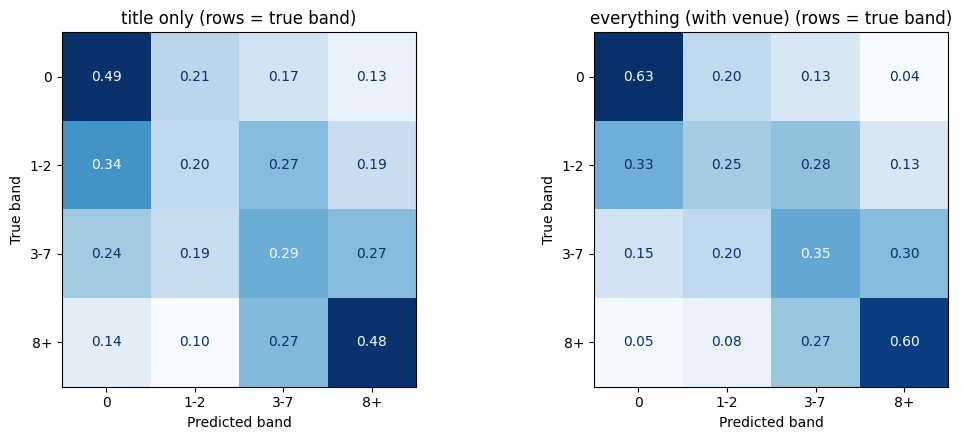

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt

test = df[df["split"] == "test"].copy()
test["venue"] = test["venue"].fillna("Unknown")
test["log_refs"] = np.log1p(test["n_references"])
LABELS = ["0", "1-2", "3-7", "8+"]

rows, cms = [], {}
dm = DummyClassifier(strategy="most_frequent").fit(dev[["year"]], dev["band"])
pm = dm.predict(test[["year"]])
rows.append({"features": "majority baseline",
             "test_accuracy": round(accuracy_score(test["band"], pm), 3),
             "test_macro_f1": round(f1_score(test["band"], pm, average="macro"), 3)})

for name, parts in configs.items():
    pipe = Pipeline([
        ("cols", ColumnTransformer([make_block(p) for p in parts])),
        ("clf", LogisticRegression(max_iter=2000, C=1.0)),
    ]).fit(dev, dev["band"])
    p_ = pipe.predict(test)
    f1s = f1_score(test["band"], p_, average=None)
    rows.append({"features": name,
                 "test_accuracy": round(accuracy_score(test["band"], p_), 3),
                 "test_macro_f1": round(f1_score(test["band"], p_, average="macro"), 3),
                 "f1_band0": round(f1s[0], 3), "f1_band1": round(f1s[1], 3),
                 "f1_band2": round(f1s[2], 3), "f1_band3": round(f1s[3], 3)})
    cms[name] = confusion_matrix(test["band"], p_, normalize="true")

final = pd.DataFrame(rows)
print(final.to_string(index=False))
final.to_csv("/kaggle/working/test_results.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name in zip(axes, ["title only", "everything (with venue)"]):
    ConfusionMatrixDisplay(cms[name], display_labels=LABELS).plot(
        ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
    ax.set_title(name + " (rows = true band)")
    ax.set_xlabel("Predicted band"); ax.set_ylabel("True band")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/confusion_matrices.png", dpi=150)
plt.show()